https://medium.com/data-science/gradient-descent-from-scratch-e8b75fa986cc

https://www.datacamp.com/tutorial/tutorial-gradient-descent

In [3]:
#Importing libraries
import numpy as np
import matplotlib.pyplot as plt

def mean_squared_error(y_true, y_predicted):

   # Calculating the loss or cost
   cost = np.sum((y_true-y_predicted)**2) / len(y_true)
   return cost


In [4]:
# Gradient descent function
# Here iterations, learning rate, stopping threshold are hyperparameters that can be tuned
def gradient_descent(x, y, iterations = 1000, learning_rate = 0.0001, stopping_threshold = 1e-6):

   #Initialzing rate, bias, learning rate, and iterations
   current_rate = 0.1
   current_bias = 0.01
   current_weight = 0.5
   iterations = iterations
   learning_rate = learning_rate
   n = float(len(x))

   costs = []
   weights = []
   previous_cost = None

   print("starting gd",iterations)
   # Estimation of optimal parameters
   for i in range(iterations):

      # Making predictions
      y_predicted = (current_weight * x) + current_bias

      # Calculating the current cost
      current_cost = mean_squared_error(y, y_predicted)

      # If the change in cost is less than or equal to stopping threshold we stop the gradient descent
      if previous_cost and abs(previous_cost - current_cost) <= stopping_threshold:
         break

      previous_cost = current_cost

      costs.append(current_cost)
      weights.append(current_weight)

      # Calculating the gradients
      weight_derivative = -(2/n) * sum(x * (y-y_predicted))
      bias_derivative = -(2/n) * sum(y-y_predicted)

      # Updating weights and bias
      current_weight = current_weight - (learning_rate * weight_derivative)
      current_bias = current_bias - (learning_rate * bias_derivative)

      # Printing the parameters
      print(f"Iteration {i+1}: Cost {current_cost}, Weight  {current_weight}, Bias {current_bias}")


   # Visualizing the weights and cost for all iterations
   plt.figure(figsize = (8,6))
   plt.plot(weights, costs)
   plt.scatter(weights, costs, marker = 'o', color = 'red')
   plt.title("Cost vs Weights")
   plt.ylabel("Cost")
   plt.xlabel("Weights")
   plt.show()

   return current_weight, current_bias

starting gd 2000
Iteration 1: Cost 2121.08585, Weight  0.9542296600000001, Bias 0.018883000000000004
Iteration 2: Cost 583.7298950363673, Weight  1.176648187302892, Bias 0.023229194474560004
Iteration 3: Cost 215.12159194963982, Weight  1.2855578894914488, Bias 0.025353893133633017
Iteration 4: Cost 126.7412262477797, Weight  1.3388867693572548, Bias 0.026390812386323667
Iteration 5: Cost 105.55046881154604, Weight  1.3649998991967562, Bias 0.02689508871858357
Iteration 6: Cost 100.46960927135571, Weight  1.3777865430551397, Bias 0.027138550707259436
Iteration 7: Cost 99.25138291091378, Weight  1.3840477291018658, Bias 0.027254302151255468
Iteration 8: Cost 98.9592912272781, Weight  1.3871136542437914, Bias 0.027307518763472188
Iteration 9: Cost 98.88925672579713, Weight  1.388614985368643, Bias 0.02733011453574948
Iteration 10: Cost 98.8724643643457, Weight  1.389350196132214, Bias 0.027337716498921798
Iteration 11: Cost 98.8684377484017, Weight  1.389710267785056, Bias 0.027337976597

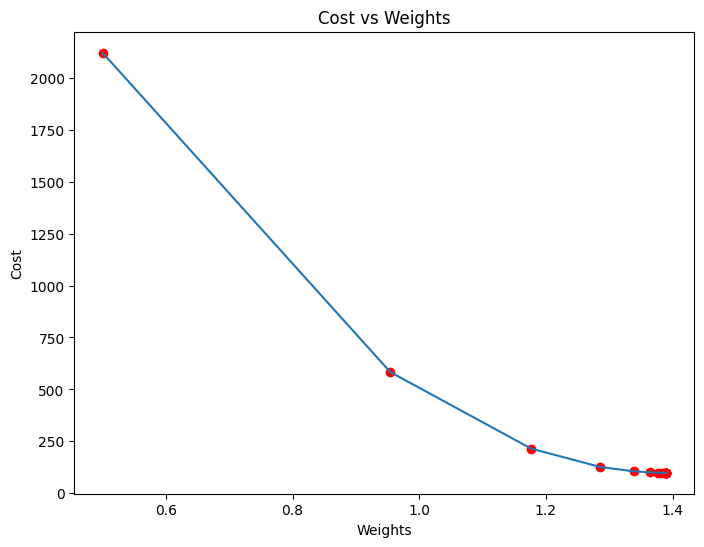

Estimated Weight: 1.390051658639904
Estimated Bias: 0.027303937196462777


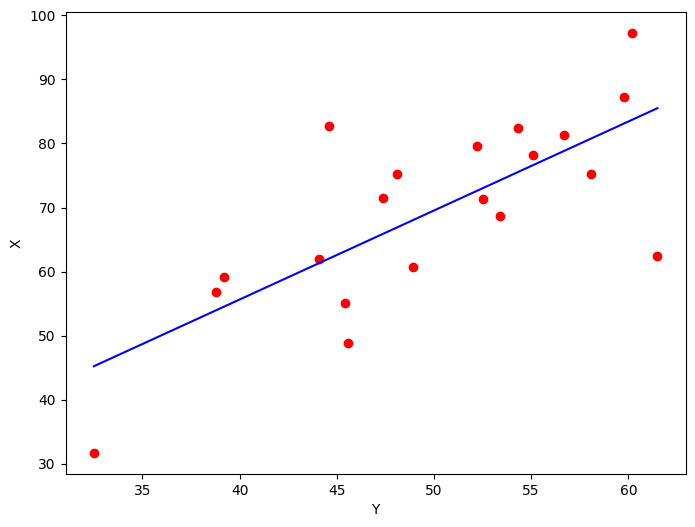

In [5]:

   # Data
   X = np.array([32.5, 53.4, 61.5, 47.4, 59.8,
   55.1, 52.2, 39.2, 48.1, 52.5,
   45.4, 54.3, 44.1, 58.1, 56.7,
   48.9, 44.6, 60.2, 45.6, 38.8])
   Y = np.array([31.7, 68.7, 62.5, 71.5, 87.2,
   78.2, 79.6, 59.1, 75.3, 71.3,
   55.1, 82.4, 62.0, 75.3, 81.4,
   60.7, 82.8, 97.3, 48.8, 56.8])

   # Estimating weight and bias using gradient descent
   estimated_weight, estimated_bias = gradient_descent(X, Y, iterations = 2000)
   print(f"Estimated Weight: {estimated_weight}\nEstimated Bias: {estimated_bias}")

   # Making predictions using estimated parameters
   Y_pred = estimated_weight*X + estimated_bias

   #Plotting the regression line
   plt.figure(figsize = (8,6))
   plt.scatter(X, Y, marker = 'o', color = 'red')
   plt.plot([min(X), max(X)], [min(Y_pred), max(Y_pred)], color = 'blue')
   plt.ylabel("X")
   plt.xlabel("Y")
   plt.show()
